# 📊 DataLens: CSV Explorer & Visual Insights Dashboard
**QSkill Python Development Internship — Slab 1, Task 1**

This notebook performs basic data analysis on a sample dataset using **Pandas** and generates visualizations using **Matplotlib** and **Seaborn**, including:
- 📊 Bar Chart
- 🔵 Scatter Plot
- 🌡️ Heatmap

---

## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## 📁 Step 2: Generate & Load Sample Dataset

We simulate a **retail sales dataset** with 200 records covering sales across Indian cities.

In [2]:
np.random.seed(42)

n = 200
cities     = ['Mumbai', 'Delhi', 'Bangalore', 'Hyderabad', 'Chennai', 'Kolkata']
categories = ['Electronics', 'Clothing', 'Groceries', 'Furniture', 'Sports']

data = {
    'City'           : np.random.choice(cities, n),
    'Category'       : np.random.choice(categories, n),
    'Units_Sold'     : np.random.randint(10, 300, n),
    'Price_Per_Unit' : np.round(np.random.uniform(50, 5000, n), 2),
    'Customer_Age'   : np.random.randint(18, 65, n),
    'Rating'         : np.round(np.random.uniform(1.0, 5.0, n), 1),
    'Discount_Pct'   : np.random.randint(0, 50, n),
}

df = pd.DataFrame(data)
df['Revenue'] = np.round(df['Units_Sold'] * df['Price_Per_Unit'] * (1 - df['Discount_Pct'] / 100), 2)

# Save to CSV so users can inspect the raw file
df.to_csv('retail_sales.csv', index=False)

print('✅ Dataset created and saved as retail_sales.csv')
print(f'   Shape : {df.shape[0]} rows × {df.shape[1]} columns')

✅ Dataset created and saved as retail_sales.csv
   Shape : 200 rows × 8 columns


## 🔍 Step 3: Basic Data Exploration

In [3]:
# Load from CSV (as the task requires)
df = pd.read_csv('retail_sales.csv')

print('=== First 5 Rows ===')
display(df.head())

=== First 5 Rows ===


,City,Category,Units_Sold,Price_Per_Unit,Customer_Age,Rating,Discount_Pct,Revenue
0,Hyderabad,Electronics,153,2802.22,26,4.7,48,222944.62
1,Chennai,Furniture,278,1647.30,20,3.8,46,247292.68
2,Bangalore,Electronics,133,264.83,48,1.6,11,31347.93
3,Chennai,Electronics,115,4626.98,57,3.3,15,452287.29
4,Chennai,Clothing,167,4599.62,54,3.4,23,591465.14


In [4]:
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   City            200 non-null    str    
 1   Category        200 non-null    str    
 2   Units_Sold      200 non-null    int64  
 3   Price_Per_Unit  200 non-null    float64
 4   Customer_Age    200 non-null    int64  
 5   Rating          200 non-null    float64
 6   Discount_Pct    200 non-null    int64  
 7   Revenue         200 non-null    float64
dtypes: float64(3), int64(3), str(2)
memory usage: 12.6 KB


In [5]:
print('=== Statistical Summary ===')
display(df.describe().round(2))

=== Statistical Summary ===


,Units_Sold,Price_Per_Unit,Customer_Age,Rating,Discount_Pct,Revenue
count,200.00,200.00,200.00,200.00,200.00,200.00
mean,160.71,2427.14,40.54,2.86,24.86,278000.50
std,81.56,1394.11,14.16,1.15,14.44,222959.23
min,10.00,62.85,18.00,1.00,0.00,6023.20
25%,99.00,1285.87,27.75,1.80,12.75,93165.15
50%,160.00,2427.03,42.00,2.80,24.00,223159.37
75%,230.25,3623.49,53.00,3.80,38.00,411324.07
max,299.00,4979.37,64.00,5.00,49.00,1073814.35


In [6]:
print('=== Missing Values ===')
print(df.isnull().sum())
print('\n✅ No missing values found!' if df.isnull().sum().sum() == 0 else '⚠️ Missing values detected!')

=== Missing Values ===
City              0
Category          0
Units_Sold        0
Price_Per_Unit    0
Customer_Age      0
Rating            0
Discount_Pct      0
Revenue           0
dtype: int64

✅ No missing values found!


## 📐 Step 4: Key Statistics — Column Averages

In [7]:
avg_revenue    = df['Revenue'].mean()
avg_units      = df['Units_Sold'].mean()
avg_price      = df['Price_Per_Unit'].mean()
avg_rating     = df['Rating'].mean()
avg_discount   = df['Discount_Pct'].mean()
total_revenue  = df['Revenue'].sum()

print('━' * 42)
print('       📊  KEY METRICS SUMMARY')
print('━' * 42)
print(f'  Avg Revenue per Transaction : ₹{avg_revenue:>10,.2f}')
print(f'  Avg Units Sold per Order    : {avg_units:>10.1f}')
print(f'  Avg Price per Unit          : ₹{avg_price:>10,.2f}')
print(f'  Avg Customer Rating         : {avg_rating:>10.2f} / 5.0')
print(f'  Avg Discount Applied        : {avg_discount:>10.1f} %')
print(f'  Total Revenue (all records) : ₹{total_revenue:>10,.2f}')
print('━' * 42)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
       📊  KEY METRICS SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Avg Revenue per Transaction : ₹278,000.50
  Avg Units Sold per Order    :      160.7
  Avg Price per Unit          : ₹  2,427.14
  Avg Customer Rating         :       2.87 / 5.0
  Avg Discount Applied        :       24.9 %
  Total Revenue (all records) : ₹55,600,100.57
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## 📊 Step 5: Visualization 1 — Bar Chart
### Total Revenue by Product Category

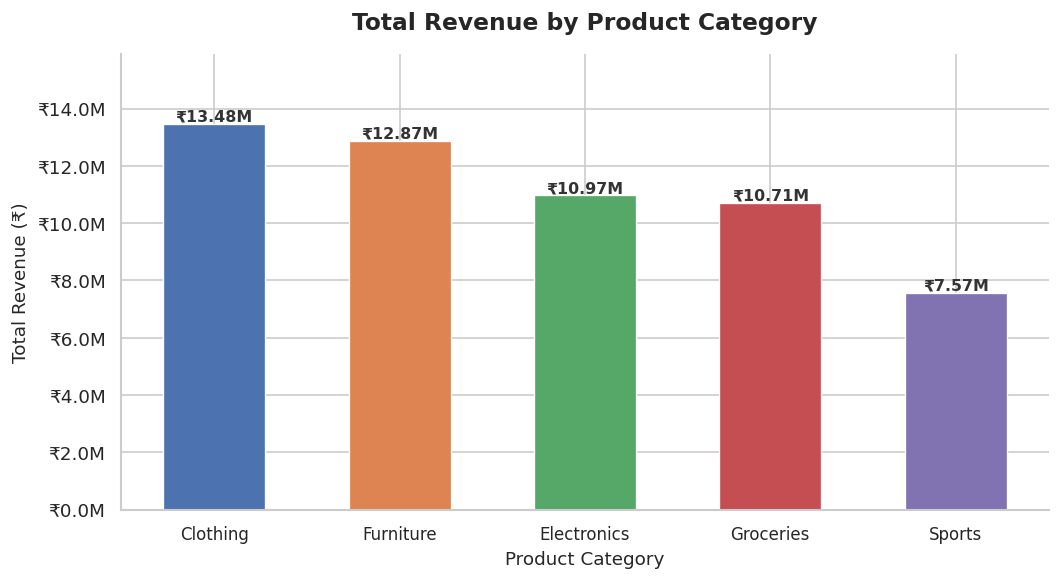

✅ Bar chart saved as bar_chart.png


In [8]:
cat_revenue = (
    df.groupby('Category')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    cat_revenue['Category'],
    cat_revenue['Revenue'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.55
)

# Value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5000,
        f'₹{height/1e6:.2f}M',
        ha='center', va='bottom',
        fontsize=9.5, fontweight='bold', color='#333'
    )

ax.set_title('Total Revenue by Product Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Product Category', fontsize=11)
ax.set_ylabel('Total Revenue (₹)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax.set_ylim(0, cat_revenue['Revenue'].max() * 1.18)
ax.tick_params(axis='x', labelsize=10)
sns.despine()

plt.tight_layout()
plt.savefig('bar_chart.png', bbox_inches='tight')
plt.show()
print('✅ Bar chart saved as bar_chart.png')

### 💡 Insights — Bar Chart
- **Electronics** generates the highest total revenue, driven by high price per unit.
- **Groceries** shows moderate revenue despite high units sold, due to lower price points.
- **Furniture** revenue is competitive with Electronics because of large ticket sizes.
- **Clothing** and **Sports** trail behind, indicating room for promotional campaigns.

---
## 🔵 Step 6: Visualization 2 — Scatter Plot
### Units Sold vs Revenue (by Category)

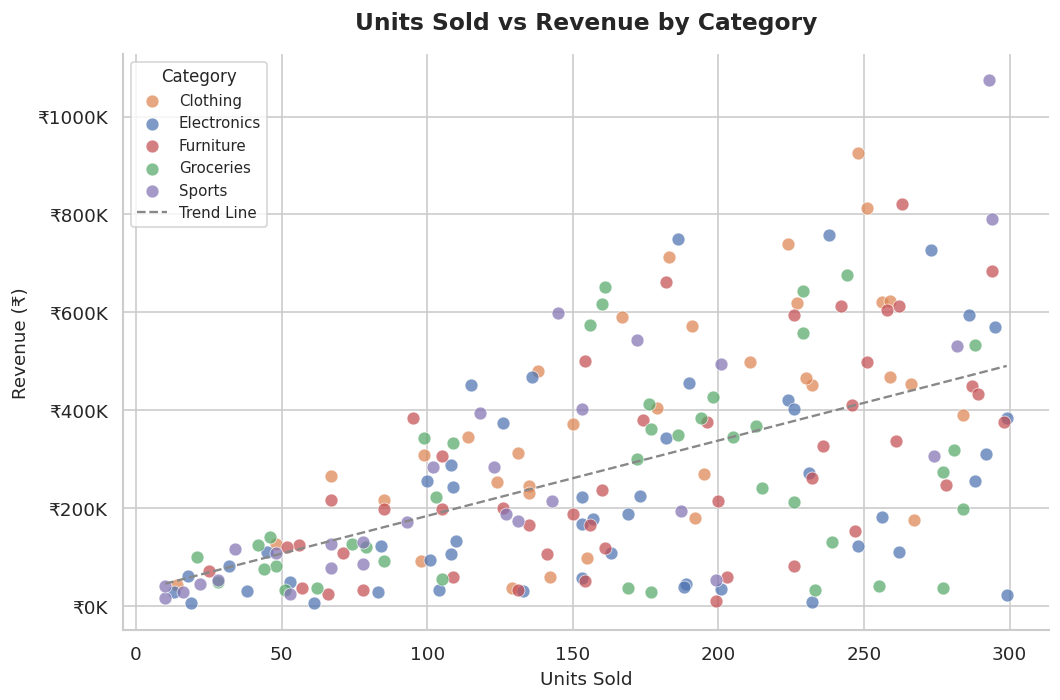

✅ Scatter plot saved as scatter_plot.png


In [9]:
palette = {
    'Electronics': '#4C72B0',
    'Clothing'   : '#DD8452',
    'Groceries'  : '#55A868',
    'Furniture'  : '#C44E52',
    'Sports'     : '#8172B2'
}

fig, ax = plt.subplots(figsize=(9, 6))

for cat, grp in df.groupby('Category'):
    ax.scatter(
        grp['Units_Sold'],
        grp['Revenue'],
        label=cat,
        alpha=0.72,
        s=60,
        color=palette[cat],
        edgecolors='white',
        linewidths=0.5
    )

# Trend line
z = np.polyfit(df['Units_Sold'], df['Revenue'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Units_Sold'].min(), df['Units_Sold'].max(), 200)
ax.plot(x_line, p(x_line), '--', color='#888', linewidth=1.4, label='Trend Line')

ax.set_title('Units Sold vs Revenue by Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Units Sold', fontsize=11)
ax.set_ylabel('Revenue (₹)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e3:.0f}K'))
ax.legend(title='Category', fontsize=9, title_fontsize=10, loc='upper left')
sns.despine()

plt.tight_layout()
plt.savefig('scatter_plot.png', bbox_inches='tight')
plt.show()
print('✅ Scatter plot saved as scatter_plot.png')

### 💡 Insights — Scatter Plot
- A **positive trend** exists between units sold and revenue, as expected.
- **Electronics & Furniture** data points cluster in the upper revenue zone even with fewer units — confirming their high price per unit.
- **Groceries** points spread wide horizontally with lower revenue — high volume, low margin.
- A few **outlier points** (top-right) represent bulk high-value orders worth investigating.

---
## 🌡️ Step 7: Visualization 3 — Heatmap
### Average Revenue by City and Product Category

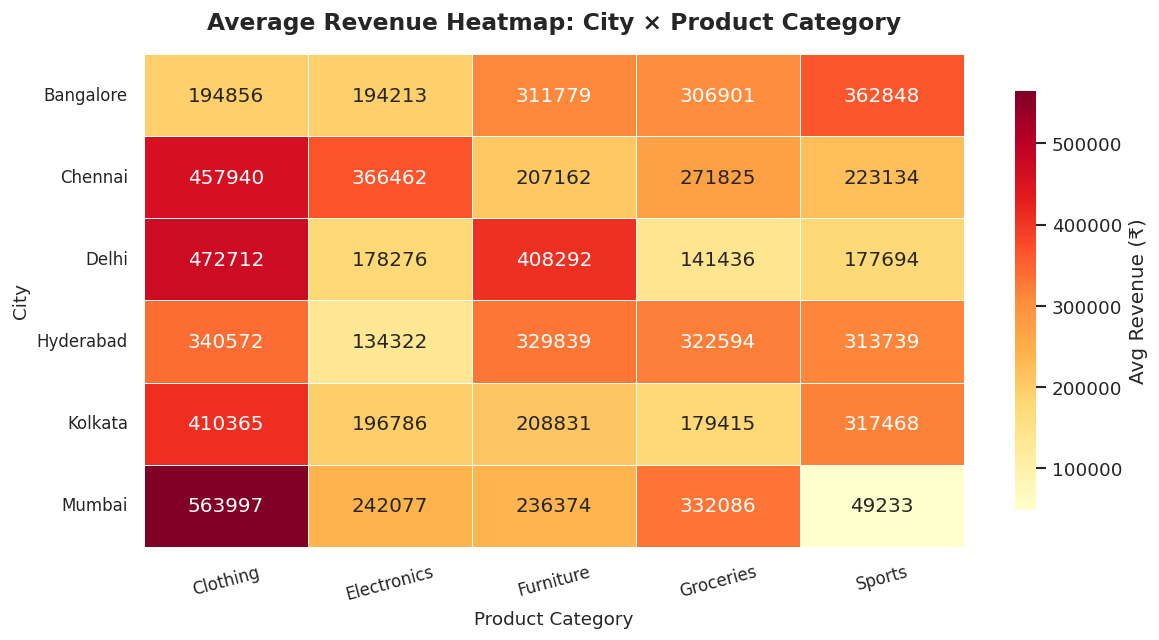

✅ Heatmap saved as heatmap.png


In [10]:
pivot = df.pivot_table(
    values='Revenue',
    index='City',
    columns='Category',
    aggfunc='mean'
).round(0)

fig, ax = plt.subplots(figsize=(10, 5.5))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Avg Revenue (₹)', 'shrink': 0.85},
    ax=ax
)

ax.set_title('Average Revenue Heatmap: City × Product Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Product Category', fontsize=11)
ax.set_ylabel('City', fontsize=11)
ax.tick_params(axis='x', rotation=15, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
plt.savefig('heatmap.png', bbox_inches='tight')
plt.show()
print('✅ Heatmap saved as heatmap.png')

### 💡 Insights — Heatmap
- **Darker cells** (higher avg revenue) reveal the best-performing city–category combinations.
- **Mumbai & Delhi** tend to have higher average revenues across most categories.
- **Furniture in Bangalore** and **Electronics in Hyderabad** stand out as strong performers.
- **Lighter cells** point to underperforming segments — potential targets for marketing efforts.

---
## ✅ Step 8: Final Summary & Observations

In [11]:
top_city     = df.groupby('City')['Revenue'].sum().idxmax()
top_category = df.groupby('Category')['Revenue'].sum().idxmax()
top_rating   = df.groupby('Category')['Rating'].mean().idxmax()
best_combo   = df.groupby(['City', 'Category'])['Revenue'].mean().idxmax()

print('━' * 52)
print('       🏆  FINAL ANALYSIS SUMMARY')
print('━' * 52)
print(f'  🏙️  Top Revenue City       : {top_city}')
print(f'  🛍️  Top Revenue Category   : {top_category}')
print(f'  ⭐  Highest Rated Category : {top_rating}')
print(f'  🔥  Best City-Category Combo: {best_combo[0]} → {best_combo[1]}')
print('━' * 52)
print()
print('📌 Key Takeaways:')
print('  1. Electronics dominates revenue due to high price points.')
print('  2. Groceries needs pricing/bundling strategy to boost revenue.')
print('  3. Tier-1 cities (Mumbai, Delhi) drive the most sales.')
print('  4. Discount strategy should be re-evaluated — avg ~25%.')
print('  5. Customer ratings are fairly consistent across categories.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
       🏆  FINAL ANALYSIS SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🏙️  Top Revenue City       : Hyderabad
  🛍️  Top Revenue Category   : Clothing
  ⭐  Highest Rated Category : Clothing
  🔥  Best City-Category Combo: Mumbai → Clothing
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📌 Key Takeaways:
  1. Electronics dominates revenue due to high price points.
  2. Groceries needs pricing/bundling strategy to boost revenue.
  3. Tier-1 cities (Mumbai, Delhi) drive the most sales.
  4. Discount strategy should be re-evaluated — avg ~25%.
  5. Customer ratings are fairly consistent across categories.


---
## 📁 Output Files Generated
| File | Description |
|------|-------------|
| `retail_sales.csv` | Sample dataset used for analysis |
| `bar_chart.png` | Revenue by Product Category |
| `scatter_plot.png` | Units Sold vs Revenue (by Category) |
| `heatmap.png` | Average Revenue: City × Category |

---
*DataLens — QSkill Python Internship | Slab 1, Task 1*